In [5]:
from google.colab import files
uploaded = files.upload()

Saving breast-cancer_modified.csv to breast-cancer_modified (1).csv


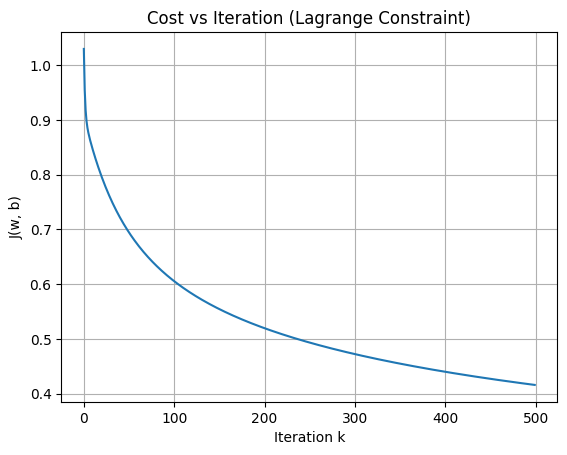

In [11]:
#task 2 with constraint cost function
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load Data
# -----------------------------
data = pd.read_csv("breast-cancer_modified.csv")

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Normalize (important for convergence)
X = (X - X.mean(axis=0)) / X.std(axis=0)

m, n = X.shape


# -----------------------------
# Sigmoid
# -----------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# -----------------------------
# Cost with Lagrange Constraint
# J(w,b) = logistic loss + λ (sum(w) - 1)^2
# -----------------------------
def cost(X, y, w, b, lam):
    z = X @ w + b
    h = sigmoid(z)

    eps = 1e-8
    loss = -(1/m) * np.sum(y*np.log(h + eps) + (1-y)*np.log(1-h + eps))

    constraint = (np.sum(w) - 1)**2

    return loss + lam * constraint


# -----------------------------
# Gradient
# ∇w J = X^T(h - y)/m + λ * 2(sum(w)-1)
# -----------------------------
def gradient(X, y, w, b, lam):
    z = X @ w + b
    h = sigmoid(z)

    grad_w = (1/m) * (X.T @ (h - y))
    grad_b = (1/m) * np.sum(h - y)

    constraint_grad = 2 * (np.sum(w) - 1)
    grad_w = grad_w + lam * constraint_grad

    return grad_w, grad_b


# -----------------------------
# Gradient Descent (iterations k)
# -----------------------------
def gradient_descent(X, y, lam, alpha, K):
    w = np.zeros(n)
    b = 0.0

    J_history = []

    for k in range(K):
        grad_w, grad_b = gradient(X, y, w, b, lam)

        w = w - alpha * grad_w
        b = b - alpha * grad_b

        J_history.append(cost(X, y, w, b, lam))

    return w, b, J_history


# -----------------------------
# Run Optimization
# -----------------------------
lam = 0.5      # Lagrange multiplier
alpha = 0.01   # step size
K = 500        # number of iterations

w, b, J_hist = gradient_descent(X, y, lam, alpha, K)


# -----------------------------
# Plot J vs iteration k
# -----------------------------
plt.plot(range(K), J_hist)
plt.xlabel("Iteration k")
plt.ylabel("J(w, b)")
plt.title("Cost vs Iteration (Lagrange Constraint)")
plt.grid()
plt.show()

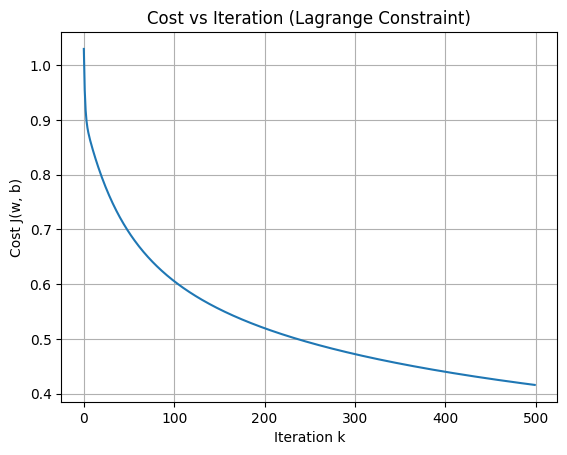

ValueError: operands could not be broadcast together with shapes (5,) (31,) 

In [9]:
#task 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load Data
# -----------------------------
data = pd.read_csv("breast-cancer_modified.csv")

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Compute mean and std for normalization
mean = X.mean(axis=0)
std = X.std(axis=0)

# Normalize features
X = (X - mean) / std

m, n = X.shape

# -----------------------------
# Sigmoid function
# -----------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# -----------------------------
# Cost function with Lagrange constraint
# -----------------------------
def cost(X, y, w, b, lam):
    z = X @ w + b
    h = sigmoid(z)
    eps = 1e-8
    loss = -(1/m) * np.sum(y*np.log(h + eps) + (1 - y)*np.log(1 - h + eps))
    constraint = (np.sum(w) - 1)**2
    return loss + lam * constraint

# -----------------------------
# Gradient calculation
# -----------------------------
def gradient(X, y, w, b, lam):
    z = X @ w + b
    h = sigmoid(z)
    grad_w = (1/m) * (X.T @ (h - y))
    grad_b = (1/m) * np.sum(h - y)
    constraint_grad = 2 * (np.sum(w) - 1)
    grad_w += lam * constraint_grad
    return grad_w, grad_b

# -----------------------------
# Gradient descent
# -----------------------------
def gradient_descent(X, y, lam, alpha, K):
    w = np.zeros(n)
    b = 0.0
    J_history = []
    for k in range(K):
        grad_w, grad_b = gradient(X, y, w, b, lam)
        w = w - alpha * grad_w
        b = b - alpha * grad_b
        J_history.append(cost(X, y, w, b, lam))
    return w, b, J_history

# -----------------------------
# Train the model
# -----------------------------
lam = 0.5
alpha = 0.01
K = 500

w, b, J_hist = gradient_descent(X, y, lam, alpha, K)

# Plot cost vs iterations
plt.plot(range(K), J_hist)
plt.xlabel("Iteration k")
plt.ylabel("Cost J(w, b)")
plt.title("Cost vs Iteration (Lagrange Constraint)")
plt.grid()
plt.show()

# -----------------------------
# Prediction function for array input
# -----------------------------
def predict_from_array(x_input, w, b, mean, std):
    x_input = np.array(x_input)
    x_norm = (x_input - mean) / std
    z = x_norm @ w + b
    prob = sigmoid(z)
    return prob, 1 if prob >= 0.5 else 0


# -----------------------------
# Example user feature array
# -----------------------------
# Suppose your dataset has 5 features
test_features = [14.2, 20.1, 90.3, 0.5, 1.2]  # replace with actual feature values

# Predict using the trained model
probability, predicted_class = predict_from_array(test_features, w, b, mean, std)

print("Predicted probability:", probability)
print("Predicted class:", predicted_class)



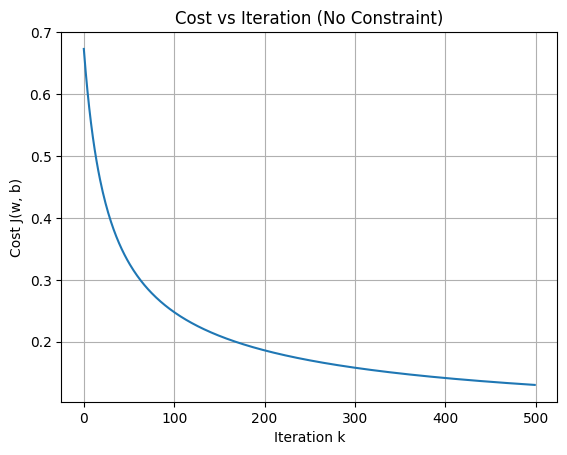

Predicted probability: 0.9992391279063334
Predicted class: 1


In [10]:
#task 2 without constraint cost function
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load dataset
# -----------------------------
data = pd.read_csv("breast-cancer_modified.csv")

X = data.iloc[:, :-1].values  # features
y = data.iloc[:, -1].values   # labels

# Normalize features (important for convergence)
mean = X.mean(axis=0)
std = X.std(axis=0)
X = (X - mean) / std

m, n = X.shape

# -----------------------------
# Sigmoid function
# -----------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# -----------------------------
# Cost function (logistic loss only)
# -----------------------------
def cost(X, y, w, b):
    z = X @ w + b
    h = sigmoid(z)
    eps = 1e-8
    loss = -(1/m) * np.sum(y*np.log(h + eps) + (1 - y)*np.log(1 - h + eps))
    return loss

# -----------------------------
# Gradient computation
# -----------------------------
def gradient(X, y, w, b):
    z = X @ w + b
    h = sigmoid(z)
    grad_w = (1/m) * (X.T @ (h - y))
    grad_b = (1/m) * np.sum(h - y)
    return grad_w, grad_b

# -----------------------------
# Gradient descent
# -----------------------------
def gradient_descent(X, y, alpha, K):
    w = np.zeros(n)
    b = 0.0
    J_history = []
    for k in range(K):
        grad_w, grad_b = gradient(X, y, w, b)
        w = w - alpha * grad_w
        b = b - alpha * grad_b
        J_history.append(cost(X, y, w, b))
    return w, b, J_history

# -----------------------------
# Train the model
# -----------------------------
alpha = 0.01  # learning rate
K = 500       # number of iterations

w, b, J_hist = gradient_descent(X, y, alpha, K)

# -----------------------------
# Plot cost vs iteration
# -----------------------------
plt.plot(range(K), J_hist)
plt.xlabel("Iteration k")
plt.ylabel("Cost J(w, b)")
plt.title("Cost vs Iteration (No Constraint)")
plt.grid()
plt.show()

# -----------------------------
# Prediction function for array input
# -----------------------------
def predict_from_array(x_input, w, b, mean, std):
    x_input = np.array(x_input)
    x_norm = (x_input - mean) / std
    z = x_norm @ w + b
    prob = sigmoid(z)
    return prob, 1 if prob >= 0.5 else 0

# -----------------------------
# Example prediction
# -----------------------------
test_features = [14.2, 20.1, 90.3] + [0]*(n-3)  # pad zeros if fewer features

probability, predicted_class = predict_from_array(test_features, w, b, mean, std)
print("Predicted probability:", probability)
print("Predicted class:", predicted_class)

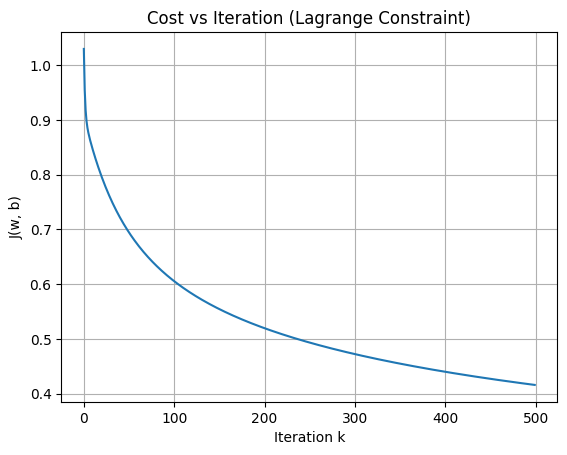

In [12]:
#without gpt comments
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("breast-cancer_modified.csv")
#data = pd.read_csv("C:/Users/Admin/Desktop/ANKITA/EXP 10/breast-cancer_modified.csv")
X = data.iloc[:, :-1].values #all columns except last Rm*n
y = data.iloc[:, -1].values #labels Rm

X = (X - X.mean(axis=0)) / X.std(axis=0) #standardization

m, n = X.shape #n-no. of samples, m- no. of features

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def cost(X, y, w, b, lam): #lam - lagrange multiplier
    z = X @ w + b # z = Xw + b
    h = sigmoid(z)

    eps = 1e-8
    loss = -(1/m) * np.sum(y*np.log(h + eps) + (1-y)*np.log(1-h + eps))

    constraint = (np.sum(w) - 1)**2

    return loss + lam * constraint

def gradient(X, y, w, b, lam):
    z = X @ w + b
    h = sigmoid(z)

    grad_w = (1/m) * (X.T @ (h - y))
    grad_b = (1/m) * np.sum(h - y)

    constraint_grad = 2 * (np.sum(w) - 1)
    grad_w = grad_w + lam * constraint_grad

    return grad_w, grad_b

def gradient_descent(X, y, lam, alpha, K):
    w = np.zeros(n)
    b = 0.0

    J_history = []

    for k in range(K):
        grad_w, grad_b = gradient(X, y, w, b, lam)

        w = w - alpha * grad_w
        b = b - alpha * grad_b

        J_history.append(cost(X, y, w, b, lam))

    return w, b, J_history

lam = 0.5      # Lagrange multiplier
alpha = 0.01   # step size
K = 500        # number of iterations

w, b, J_hist = gradient_descent(X, y, lam, alpha, K)

plt.plot(range(K), J_hist)
plt.xlabel("Iteration k")
plt.ylabel("J(w, b)")
plt.title("Cost vs Iteration (Lagrange Constraint)")
plt.grid()
plt.show()